In [2]:
import os
os.chdir('../../../../..')

In [3]:
from typing import List

from scipy.cluster.hierarchy import fcluster
from sklearn.preprocessing import StandardScaler
import numpy as np
import polars as pl

from tqdm import tqdm

from src.datasets import QM9Dataset
from src.non_euclidean import Riemann
from scripts.materials_project.euclidean_evaluation_pipeline import build_invariant_matrix, build_universal_matrix
from src.helper_functions import create_chemiscope_viewer

In [4]:
qm9 = QM9Dataset(limit=5000, sampling_strategy="stratified", stratify_by=["num_atoms", "gap"])
df = qm9.load()
frames = qm9.get_positions(invariant=False)

2026-04-14 09:33:02.187 | INFO     | src.datasets:load:485 - Loading cached full QM9 dataset from: data/QM9/dataset_cleaned.parquet
2026-04-14 09:33:02.386 | INFO     | src.datasets:_sample_qm9_df:677 - QM9 sampling complete: strategy=stratified, requested_limit=5000, returned_rows=5000.
2026-04-14 09:33:02.386 | INFO     | src.datasets:_add_requested_descriptors:125 - Applying requested QM9 descriptors to sampled dataframe (rows=5000).
2026-04-14 09:33:02.386 | INFO     | src.datasets:_add_requested_descriptors:150 - No new descriptor columns added (already present or none requested).
2026-04-14 09:33:03.786 | DEBUG    | src.datasets:get_positions:1143 - Skipping qm9_12676: Embedding failed.
2026-04-14 09:33:04.168 | DEBUG    | src.datasets:get_positions:1143 - Skipping qm9_15713: Embedding failed.
2026-04-14 09:33:04.578 | DEBUG    | src.datasets:get_positions:1143 - Skipping qm9_17078: Embedding failed.
2026-04-14 09:33:05.116 | DEBUG    | src.datasets:get_positions:1143 - Skipping 

In [5]:
mol_ids = [frame.info['mol_id'] for frame in frames]
df = df.filter(pl.col("mol_id").is_in(mol_ids))

In [6]:
riemann = Riemann()
distance_matrix = riemann.distance_matrix(frames=frames, metric="affine-invariant")

2026-04-14 09:33:35.993 | INFO     | src.non_euclidean:distance_matrix:498 - Computing Riemann distance matrix | Features: invariant | Metric: affine-invariant
Computing Distances: 100%|██████████| 4980/4980 [04:47<00:00, 17.32it/s] 


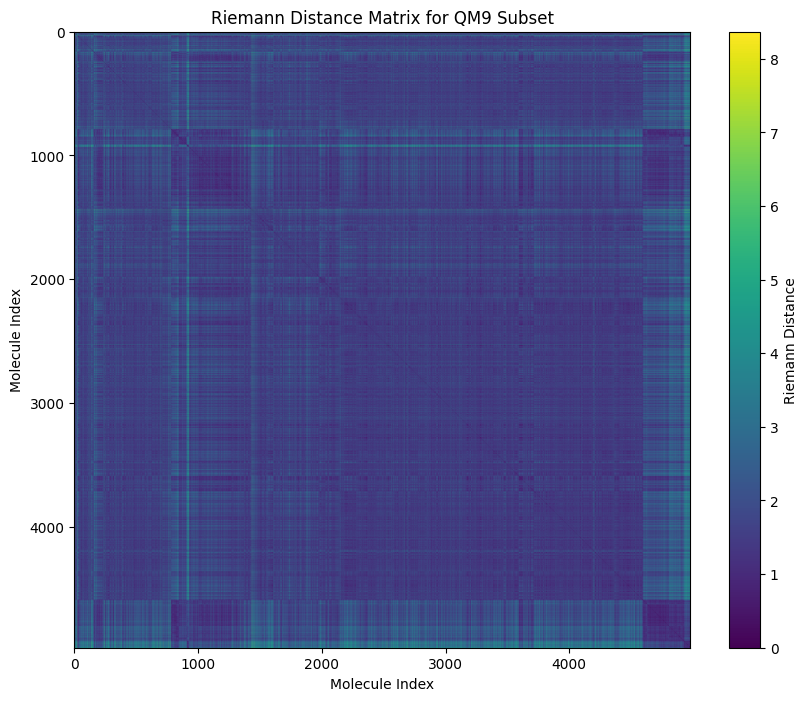

In [7]:
# plot heatmap of distance matrix
import matplotlib.pyplot as plt
plt.figure(figsize=(10, 8))
plt.imshow(distance_matrix, cmap='viridis')
plt.colorbar(label='Riemann Distance')
plt.title('Riemann Distance Matrix for QM9 Subset')
plt.xlabel('Molecule Index')
plt.ylabel('Molecule Index')
plt.show()


# Hierachial Clustering

/var/folders/_k/m1mygzyn5n7f9s1mcnb2hgxm0000gn/T/ipykernel_8853/564585408.py:24: ClusterWarning: The symmetric non-negative hollow observation matrix looks suspiciously like an uncondensed distance matrix
  linkage_matrix = linkage(distance_matrix, method='average')
Evaluating Clusters: 100%|██████████| 19/19 [01:12<00:00,  3.80s/it]


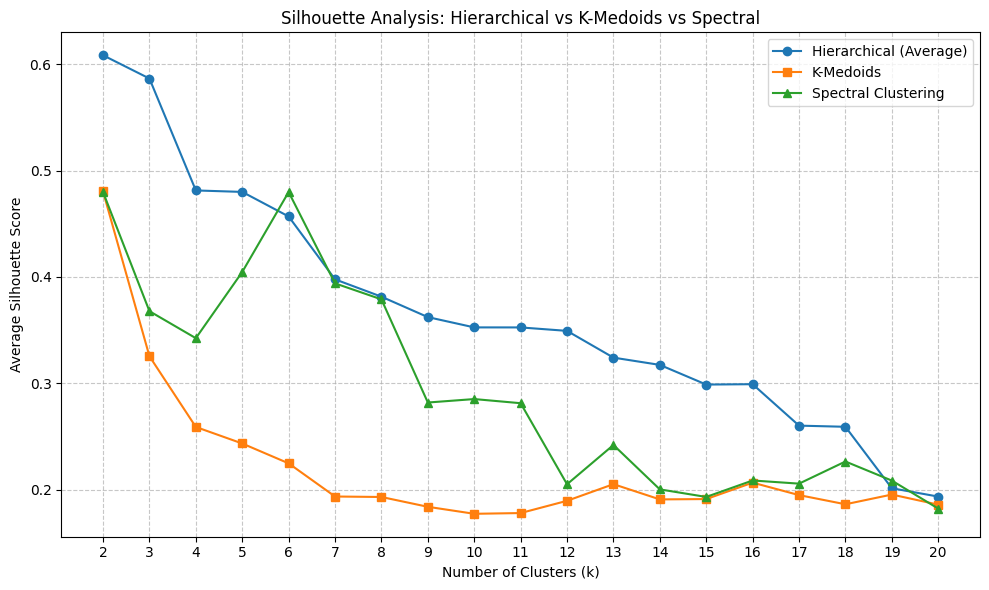

Best k for Hierarchical: 2 (Score: 0.6085)
Best k for K-Medoids:    2 (Score: 0.4804)
Best k for Spectral:     6 (Score: 0.4799)


In [8]:
import numpy as np
import kmedoids
from scipy.cluster.hierarchy import linkage, fcluster
from sklearn.cluster import SpectralClustering
from sklearn.metrics import silhouette_score
import matplotlib.pyplot as plt
from tqdm import tqdm

# =========================================
# 1. Prepare Matrices
# =========================================
# (Assuming distance_matrix is already defined)

# Convert Distance Matrix to Affinity Matrix for Spectral Clustering
# We use the median distance as the sigma scale factor (a standard heuristic)
nonzero_dists = distance_matrix[distance_matrix > 0]
sigma = np.median(nonzero_dists) if len(nonzero_dists) > 0 else 1.0

# Gaussian Kernel: similarity decays exponentially as distance increases
affinity_matrix = np.exp(- (distance_matrix ** 2) / (2 * sigma ** 2))
np.fill_diagonal(affinity_matrix, 1.0) # An item is 100% similar to itself

# Perform hierarchical clustering using the precomputed distance matrix
linkage_matrix = linkage(distance_matrix, method='average')

# =========================================
# 2. Evaluate Clusters
# =========================================
hierarchical_scores = []
kmedoids_scores = []
spectral_scores = []

k_range = range(2, 21)  # Test k from 2 to 20

for k in tqdm(k_range, desc="Evaluating Clusters"):
    # --- 1. Hierarchical Clustering ---
    labels_hier = fcluster(linkage_matrix, k, criterion='maxclust')
    sil_hier = silhouette_score(distance_matrix, labels_hier, metric='precomputed')
    hierarchical_scores.append(sil_hier)

    # --- 2. K-Medoids Clustering ---
    km_model = kmedoids.KMedoids(
        n_clusters=k, 
        metric='precomputed', 
        random_state=42
    )
    labels_km = km_model.fit_predict(distance_matrix)
    sil_km = silhouette_score(distance_matrix, labels_km, metric='precomputed')
    kmedoids_scores.append(sil_km)

    # --- 3. Spectral Clustering ---
    # NOTE: We FIT on the affinity matrix, but EVALUATE on the distance matrix!
    spectral_model = SpectralClustering(
        n_clusters=k,
        affinity='precomputed',
        assign_labels='kmeans', # standard method to assign labels after eigenvalue decomposition
        random_state=42
    )
    labels_spec = spectral_model.fit_predict(affinity_matrix)
    
    # We still use the original distance matrix to calculate Silhouette!
    sil_spec = silhouette_score(distance_matrix, labels_spec, metric='precomputed')
    spectral_scores.append(sil_spec)

# =========================================
# 3. Plotting
# =========================================
plt.figure(figsize=(10, 6))
plt.plot(k_range, hierarchical_scores, marker='o', label='Hierarchical (Average)')
plt.plot(k_range, kmedoids_scores, marker='s', label='K-Medoids')
plt.plot(k_range, spectral_scores, marker='^', label='Spectral Clustering')

plt.xlabel('Number of Clusters (k)')
plt.ylabel('Average Silhouette Score')
plt.title('Silhouette Analysis: Hierarchical vs K-Medoids vs Spectral')
plt.xticks(list(k_range))
plt.grid(True, linestyle='--', alpha=0.7)
plt.legend()
plt.tight_layout()
plt.show()

# =========================================
# 4. Results
# =========================================
best_k_hier = k_range[np.argmax(hierarchical_scores)]
best_k_km = k_range[np.argmax(kmedoids_scores)]
best_k_spec = k_range[np.argmax(spectral_scores)]

print(f"Best k for Hierarchical: {best_k_hier} (Score: {max(hierarchical_scores):.4f})")
print(f"Best k for K-Medoids:    {best_k_km} (Score: {max(kmedoids_scores):.4f})")
print(f"Best k for Spectral:     {best_k_spec} (Score: {max(spectral_scores):.4f})")

In [14]:
best_k = 5
labels = fcluster(linkage_matrix, best_k, criterion='maxclust')
df = df.with_columns(pl.Series("cluster_label", labels))
print(np.unique(labels, return_counts=True))

(array([1, 2, 3, 4, 5], dtype=int32), array([3095, 1863,    3,    4,   15]))


In [15]:
create_chemiscope_viewer(df, distance_matrix, labels, reduction_method="PCA")

Running PCA dimensionality reduction...
Converting structures/molecules to ASE Atoms for Chemiscope...
Assembling properties for Chemiscope...
Generating Chemiscope widget...
Saved Chemiscope input to: qm9_PCA_clustering.json
If the viewer does not open automatically, run `chemiscope show qm9_PCA_clustering.json`.


<ChemiscopeWidget(meta={'name': 'QM9 - PCA Clustering'}, settings={'map': {'x': {'property': 'PCA_1'}, 'y': {'…

In [16]:
def average_numeric_by_cluster(df: pl.DataFrame) -> pl.DataFrame:
    """
    Groups a Polars DataFrame by 'cluster_label' and returns 
    the mean of all numeric columns along with the count of elements.
    """
    return (
        df.group_by("cluster_label")
        .agg(
            pl.len().alias("count"),  # Adds the number of elements per cluster
            pl.col(pl.NUMERIC_DTYPES).mean()
        )
        .sort("cluster_label")
    )

print("Hierarchical Clustering")
cluster_averages = average_numeric_by_cluster(df)
with pl.Config(set_tbl_cols=-1, set_tbl_width_chars=1000, set_tbl_rows=-1):
    print(cluster_averages)


Hierarchical Clustering
shape: (5, 55)
┌───────────────┬───────┬───────────┬────────────┬───────────┬───────────┬───────────────────┬─────────────────────┬─────────────────┬───────────┬────────────────────┬──────────────┬─────────────────────┬───────────────┬───────────────┬───────────────┬───────────────┬──────────────────┬─────────────────┬────────────────┬─────────────────┬─────────────────┬───────────────────┬─────────────────┬─────────────────┬────────────┬────────────┬───────────┬──────────┬──────────┬────────────────────┬──────────┬───────────┬──────────┬──────────┬────────────┬──────────┬───────────┬───────────┬───────────┬──────────┬─────────────┬──────────┬───────────────┬───────────────┬───────────────┬───────────────┬───────────┬────────────┬────────────┬────────────┬────────────┬──────────┬──────────┬──────────┐
│ cluster_label ┆ count ┆ num_atoms ┆ mol_weight ┆ logp      ┆ tpsa      ┆ election_affinity ┆ ionization_energies ┆ num_heavy_atoms ┆ num_rings ┆ num_aromatic_rin

/var/folders/_k/m1mygzyn5n7f9s1mcnb2hgxm0000gn/T/ipykernel_8853/631317584.py:10: DeprecationWarning: `NUMERIC_DTYPES` was deprecated in version 1.0.0. Define your own data type groups or use the `polars.selectors` module for selecting columns of a certain data type.
  pl.col(pl.NUMERIC_DTYPES).mean()


/Users/karlfindhansen/thesis/Anomaly-Detection-in-Molecular-and-Materials-Datasets/.venv/lib/python3.12/site-packages/sklearn/manifold/_mds.py:744: FutureWarning: The default value of `n_init` will change from 4 to 1 in 1.9. To suppress this warning, provide some value of `n_init`.
  warnings.warn(
/Users/karlfindhansen/thesis/Anomaly-Detection-in-Molecular-and-Materials-Datasets/.venv/lib/python3.12/site-packages/sklearn/manifold/_mds.py:754: FutureWarning: The default value of `init` will change from 'random' to 'classical_mds' in 1.10. To suppress this warning, provide some value of `init`.
  warnings.warn(


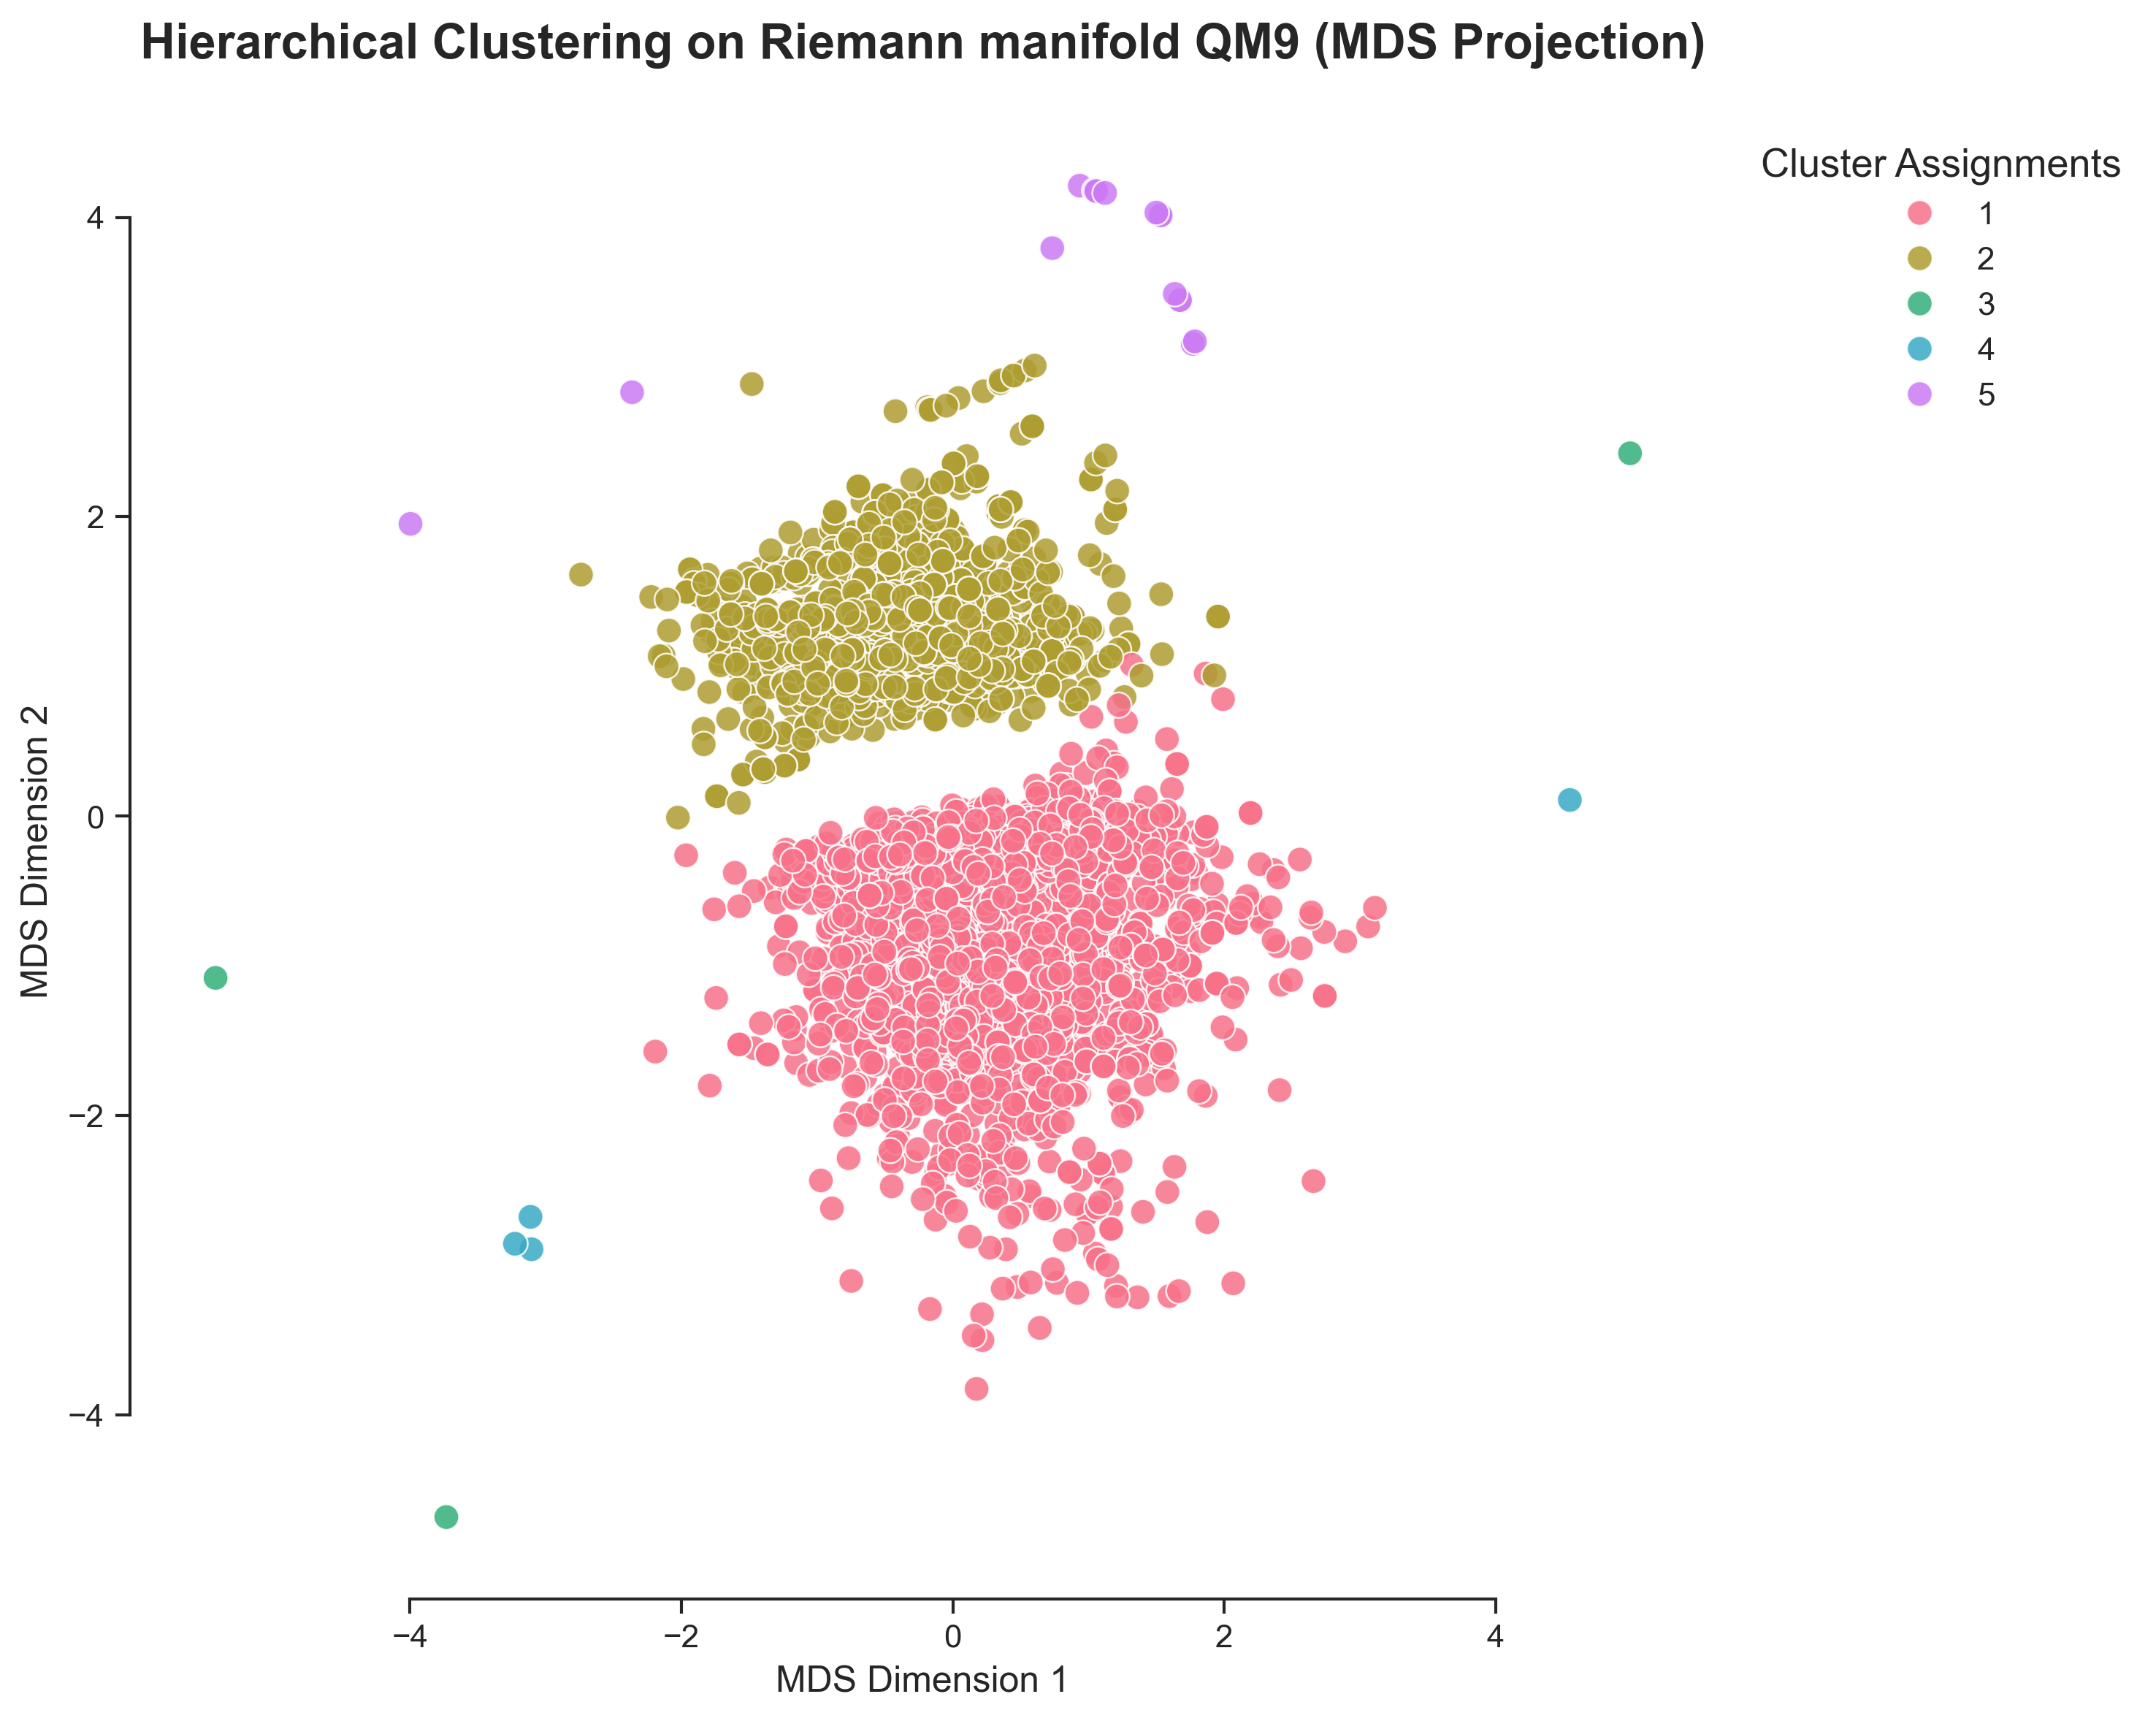

In [17]:
# make a beautiful plot of all the clusters where it is projected using mds and save it
# 1. Setup UMAP (added n_neighbors and min_dist for better aesthetic tuning)
# umap_reducer = UMAP(n_components=2, metric='euclidean', n_neighbors=15, min_dist=0.1, random_state=42)
# umap_embedding = umap_reducer.fit_transform(scaled_matrix)
import seaborn as sns
from sklearn.manifold import TSNE, MDS

mds = MDS(n_components=2, random_state=42, metric='precomputed')
mds_embedding = mds.fit_transform(distance_matrix)

# pca reducer
# pca_reducer = PCA(n_components=2, random_state=42)
# pca_embedding = pca_reducer.fit_transform(scaled_matrix)

# 2. Setup Professional Plot Style
sns.set_theme(style="ticks", context="paper", font_scale=1.2)
fig, ax = plt.subplots(figsize=(10, 8), dpi=300) # High DPI makes it crisp for papers/presentations

# Convert labels to numpy array for boolean masking
labels = np.array(labels)
unique_labels = np.unique(labels)
n_clusters = len([l for l in unique_labels if l != -1])

# 3. Plot Noise First (so it stays in the background!)
noise_mask = (labels == -1)
if noise_mask.any():
    ax.scatter(
        mds_embedding[noise_mask, 0], 
        mds_embedding[noise_mask, 1], 
        c='#B0B0B0',        # Soft silver/grey
        s=15,               # Smaller size
        alpha=0.4,          # Highly transparent
        label='Noise (-1)',
        edgecolors='none'
    )

# 4. Plot the Valid Clusters
cluster_mask = (labels != -1)
if cluster_mask.any():
    # Use a vibrant, visually pleasing palette
    palette = sns.color_palette("husl", n_clusters)
    
    sns.scatterplot(
        x=mds_embedding[cluster_mask, 0], 
        y=mds_embedding[cluster_mask, 1], 
        hue=labels[cluster_mask], 
        palette=palette,
        s=70,               # Larger size for valid points
        alpha=0.85,         # Slight transparency to show density
        edgecolor='white',  # Adds a crisp outline to overlapping points
        linewidth=0.6,
        ax=ax,
        legend='full'
    )

# 5. Typography and Labels
ax.set_title('Hierarchical Clustering on Riemann manifold QM9 (MDS Projection)', 
             fontsize=16, fontweight='bold', pad=20)
ax.set_xlabel('MDS Dimension 1', fontsize=12, fontweight='medium')
ax.set_ylabel('MDS Dimension 2', fontsize=12, fontweight='medium')

# 6. Clean up the box/axes (Despine)
sns.despine(trim=True, offset=5)

# 7. Legend Formatting
# Move legend outside the plot, remove its ugly box
ax.legend(title="Cluster Assignments", 
          bbox_to_anchor=(1.02, 1), 
          loc='upper left', 
          frameon=False, 
          title_fontsize='13')

plt.tight_layout()

# Save it as a high-quality image (optional)
plt.savefig("figures/qm9/non_euclidean/riemann/invariant_features/hier_mds_clusters.png", dpi=300, bbox_inches='tight')

plt.show()

# KMedoids

In [ ]:
# kmedoids clustering
km_model = kmedoids.KMedoids(
    n_clusters=best_k,
    metric='precomputed',
    random_state=42
)
labels_km = km_model.fit_predict(distance_matrix)
df = df.with_columns(pl.Series("cluster_label", labels_km))
print(np.unique(labels_km, return_counts=True))

(array([0, 1, 2, 3, 4], dtype=uint64), array([569, 586, 474, 473, 394]))


In [ ]:
create_chemiscope_viewer(df, distance_matrix, labels_km, reduction_method="ISOMAP")

Running ISOMAP dimensionality reduction...
Converting structures/molecules to ASE Atoms for Chemiscope...


/Users/karlfindhansen/thesis/Anomaly-Detection-in-Molecular-and-Materials-Datasets/.venv/lib/python3.12/site-packages/sklearn/manifold/_isomap.py:384: UserWarning: The number of connected components of the neighbors graph is 4 > 1. Completing the graph to fit Isomap might be slow. Increase the number of neighbors to avoid this issue.
  self._fit_transform(X)
/Users/karlfindhansen/thesis/Anomaly-Detection-in-Molecular-and-Materials-Datasets/.venv/lib/python3.12/site-packages/scipy/sparse/_index.py:174: SparseEfficiencyWarning: Changing the sparsity structure of a csr_matrix is expensive. lil and dok are more efficient.
  self._set_intXint(row, col, x.flat[0])


Assembling properties for Chemiscope...
Generating Chemiscope widget...
Saved Chemiscope input to: qm9_ISOMAP_clustering.json
If the viewer does not open automatically, run `chemiscope show qm9_ISOMAP_clustering.json`.


<ChemiscopeWidget(meta={'name': 'QM9 - ISOMAP Clustering'}, settings={'map': {'x': {'property': 'ISOMAP_1'}, '…

# Spectral clustering

In [ ]:
spectral_model = SpectralClustering(
    n_clusters=9,
    affinity='precomputed',
    assign_labels='kmeans',
    random_state=42
)
labels_spec = spectral_model.fit_predict(affinity_matrix)
df = df.with_columns(pl.Series("cluster_label", labels_spec))
print(np.unique(labels_spec, return_counts=True))

(array([0, 1, 2, 3, 4, 5, 6, 7, 8], dtype=int32), array([258,   1,   8, 762, 689, 601, 138,   1,  38]))


In [ ]:
create_chemiscope_viewer(df, distance_matrix, labels_spec, reduction_method="ISOMAP")

Running ISOMAP dimensionality reduction...
Converting structures/molecules to ASE Atoms for Chemiscope...


/Users/karlfindhansen/thesis/Anomaly-Detection-in-Molecular-and-Materials-Datasets/.venv/lib/python3.12/site-packages/sklearn/manifold/_isomap.py:384: UserWarning: The number of connected components of the neighbors graph is 4 > 1. Completing the graph to fit Isomap might be slow. Increase the number of neighbors to avoid this issue.
  self._fit_transform(X)
/Users/karlfindhansen/thesis/Anomaly-Detection-in-Molecular-and-Materials-Datasets/.venv/lib/python3.12/site-packages/scipy/sparse/_index.py:174: SparseEfficiencyWarning: Changing the sparsity structure of a csr_matrix is expensive. lil and dok are more efficient.
  self._set_intXint(row, col, x.flat[0])


Assembling properties for Chemiscope...
Generating Chemiscope widget...
Saved Chemiscope input to: qm9_ISOMAP_clustering.json
If the viewer does not open automatically, run `chemiscope show qm9_ISOMAP_clustering.json`.


<ChemiscopeWidget(meta={'name': 'QM9 - ISOMAP Clustering'}, settings={'map': {'x': {'property': 'ISOMAP_1'}, '…